Resolution : 500 x 375
Data type  : uint8
Channels   : 3

Top-left 5x5 pixel values:
 [[207 208 205 201 202]
 [208 209 206 202 203]
 [205 206 203 200 201]
 [201 202 200 198 200]
 [202 203 201 199 201]]


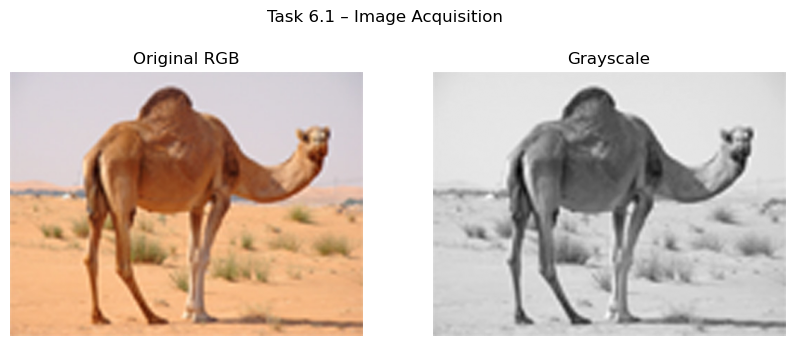

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image — put your image in same folder as notebook
img_rgb  = cv2.imread('low.jpg')
img_rgb  = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2RGB)   # fix OpenCV color
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

# Print info
print("Resolution :", img_gray.shape[1], "x", img_gray.shape[0])
print("Data type  :", img_gray.dtype)
print("Channels   :", img_rgb.shape[2])
print("\nTop-left 5x5 pixel values:\n", img_gray[:5, :5])

# Display
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(img_rgb);        ax[0].set_title('Original RGB');   ax[0].axis('off')
ax[1].imshow(img_gray, cmap='gray'); ax[1].set_title('Grayscale'); ax[1].axis('off')
plt.suptitle('Task 6.1 – Image Acquisition')
plt.show()

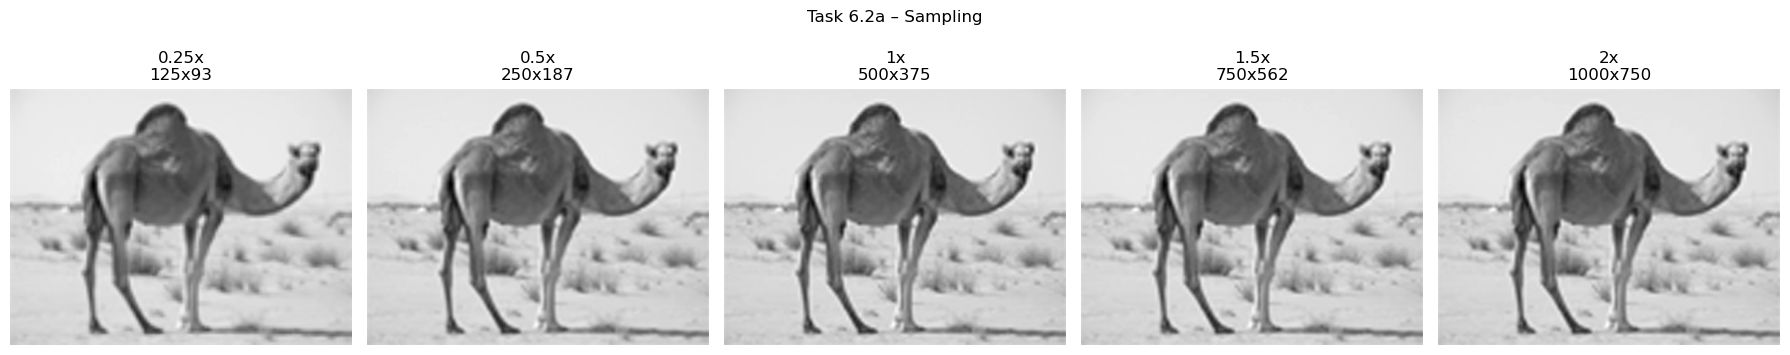

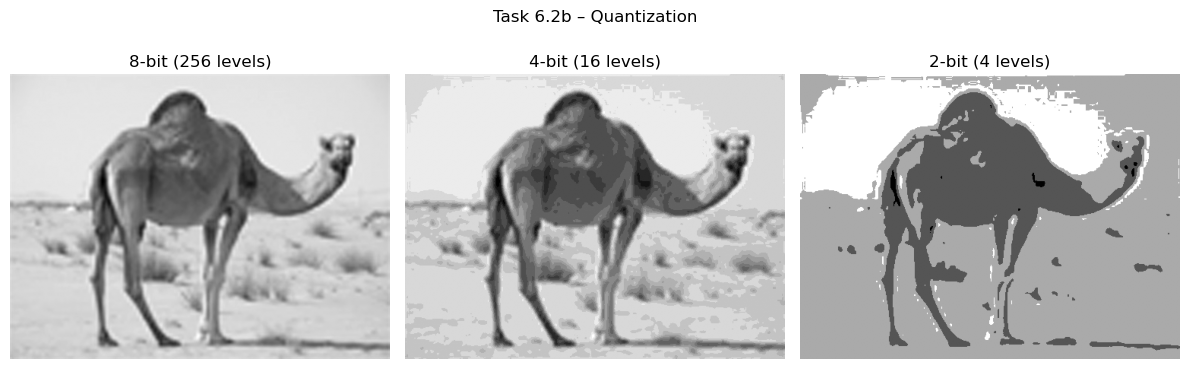

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_rgb  = cv2.imread('low.jpg')
img_rgb  = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
h, w     = img_gray.shape

# --- Sampling ---
scales = [0.25, 0.5, 1.0, 1.5, 2.0]
labels = ['0.25x', '0.5x', '1x', '1.5x', '2x']

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for i, s in enumerate(scales):
    ds  = cv2.resize(img_gray, (int(w*s), int(h*s)))
    out = cv2.resize(ds, (w, h))   # back to original size for display
    axes[i].imshow(out, cmap='gray')
    axes[i].set_title(f'{labels[i]}\n{ds.shape[1]}x{ds.shape[0]}')
    axes[i].axis('off')
plt.suptitle('Task 6.2a – Sampling')
plt.tight_layout()
plt.show()

# --- Quantization (Bit Depth) ---
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, bits in enumerate([8, 4, 2]):
    levels = 2 ** bits
    q = np.round(img_gray / 255 * (levels - 1)) * (255 / (levels - 1))
    q = q.astype(np.uint8)
    axes[i].imshow(q, cmap='gray')
    axes[i].set_title(f'{bits}-bit ({levels} levels)')
    axes[i].axis('off')
plt.suptitle('Task 6.2b – Quantization')
plt.tight_layout()
plt.show()

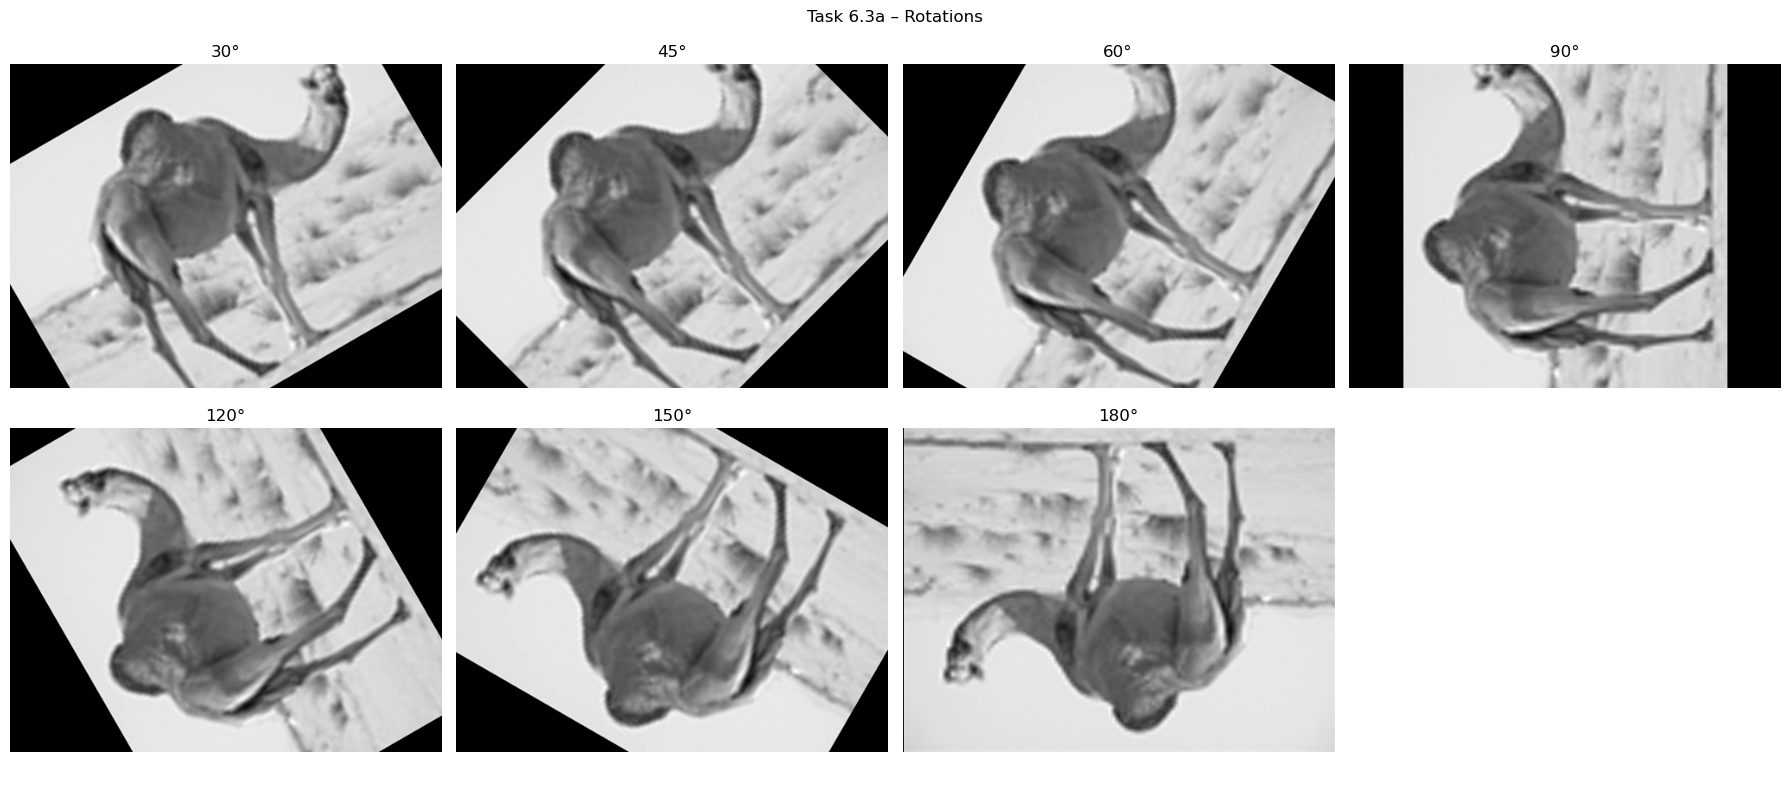

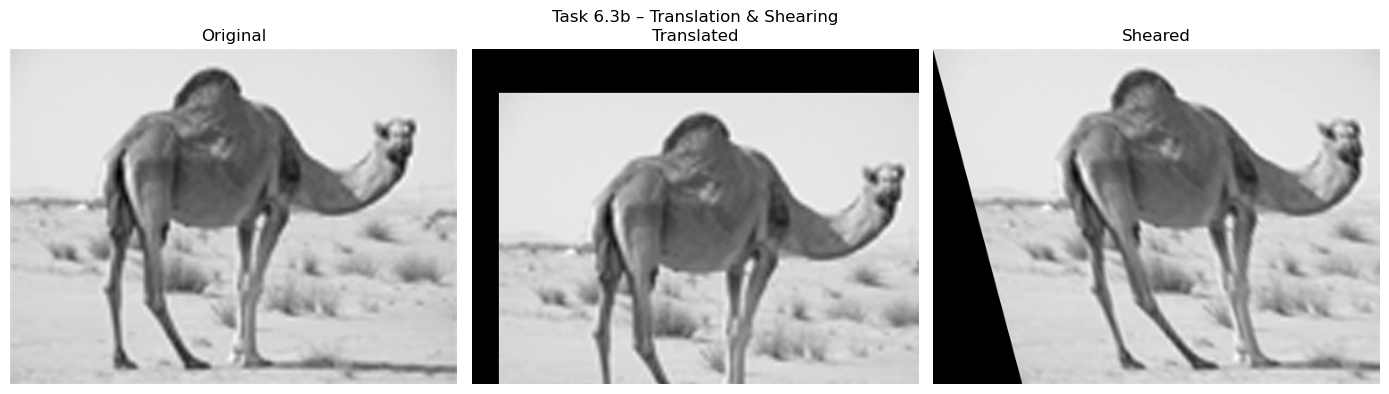

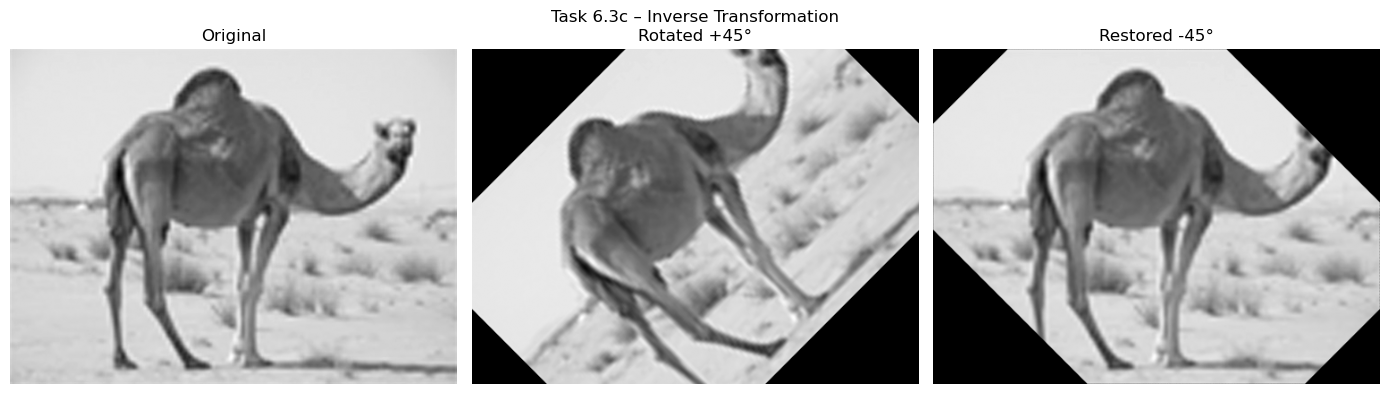

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_rgb  = cv2.imread('low.jpg')
img_rgb  = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
h, w     = img_gray.shape
cx, cy   = w // 2, h // 2

# --- Rotation ---
angles = [30, 45, 60, 90, 120, 150, 180]
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, angle in enumerate(angles):
    M   = cv2.getRotationMatrix2D((cx, cy), angle, 1.0)
    rot = cv2.warpAffine(img_gray, M, (w, h))
    axes[i].imshow(rot, cmap='gray')
    axes[i].set_title(f'{angle}°')
    axes[i].axis('off')
axes[7].axis('off')
plt.suptitle('Task 6.3a – Rotations')
plt.tight_layout()
plt.show()

# --- Translation ---
M_t = np.float32([[1, 0, 30], [0, 1, 50]])    # tx=30, ty=50
img_translated = cv2.warpAffine(img_gray, M_t, (w, h))

# --- Shearing ---
pts1 = np.float32([[0,0],[w,0],[0,h]])
pts2 = np.float32([[0,0],[w,0],[int(0.2*w),h]])
M_s  = cv2.getAffineTransform(pts1, pts2)
img_sheared = cv2.warpAffine(img_gray, M_s, (w, h))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(img_gray,       cmap='gray'); axes[0].set_title('Original');    axes[0].axis('off')
axes[1].imshow(img_translated, cmap='gray'); axes[1].set_title('Translated');  axes[1].axis('off')
axes[2].imshow(img_sheared,    cmap='gray'); axes[2].set_title('Sheared');     axes[2].axis('off')
plt.suptitle('Task 6.3b – Translation & Shearing')
plt.tight_layout()
plt.show()

# --- Inverse Transformation ---
M_fwd = cv2.getRotationMatrix2D((cx, cy),  45, 1.0)
M_inv = cv2.getRotationMatrix2D((cx, cy), -45, 1.0)
rot45    = cv2.warpAffine(img_gray, M_fwd, (w, h))
restored = cv2.warpAffine(rot45,    M_inv, (w, h))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(img_gray,  cmap='gray'); axes[0].set_title('Original');      axes[0].axis('off')
axes[1].imshow(rot45,     cmap='gray'); axes[1].set_title('Rotated +45°');  axes[1].axis('off')
axes[2].imshow(restored,  cmap='gray'); axes[2].set_title('Restored -45°'); axes[2].axis('off')
plt.suptitle('Task 6.3c – Inverse Transformation')
plt.tight_layout()
plt.show()

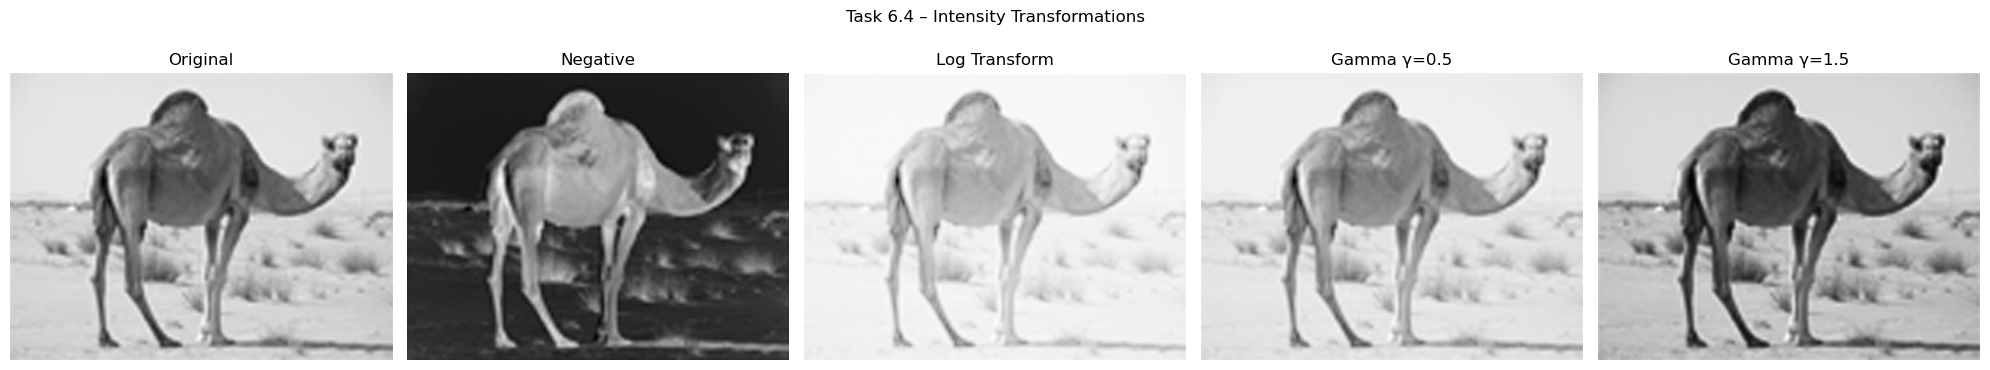

Best for brightening         : Gamma γ=0.5
Best for highlighting details: Log Transform


In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_rgb  = cv2.imread('low.jpg')
img_rgb  = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
I        = img_gray.astype(np.float64)

# Negative
img_neg  = (255 - I).astype(np.uint8)

# Log transform
c        = 255 / np.log(1 + 255)
img_log  = (c * np.log(1 + I)).astype(np.uint8)

# Gamma
g05 = (255 * (I / 255) ** 0.5).astype(np.uint8)   # brightens
g15 = (255 * (I / 255) ** 1.5).astype(np.uint8)   # darkens

titles = ['Original', 'Negative', 'Log Transform', 'Gamma γ=0.5', 'Gamma γ=1.5']
images = [img_gray,   img_neg,    img_log,          g05,            g15]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, img, title in zip(axes, images, titles):
    ax.imshow(img, cmap='gray')
    ax.set_title(title)
    ax.axis('off')
plt.suptitle('Task 6.4 – Intensity Transformations')
plt.tight_layout()
plt.show()

print("Best for brightening         : Gamma γ=0.5")
print("Best for highlighting details: Log Transform")

C:\Users\HP\AppData\Local\Temp\ipykernel_22200\4106149738.py:13: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axes[0,1].hist(img_gray.ravel(), 256, [0,256], color='gray'); axes[0,1].set_title('Original Histogram')
C:\Users\HP\AppData\Local\Temp\ipykernel_22200\4106149738.py:15: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axes[1,1].hist(img_eq.ravel(),   256, [0,256], color='gray'); axes[1,1].set_title('Equalized Histogram')


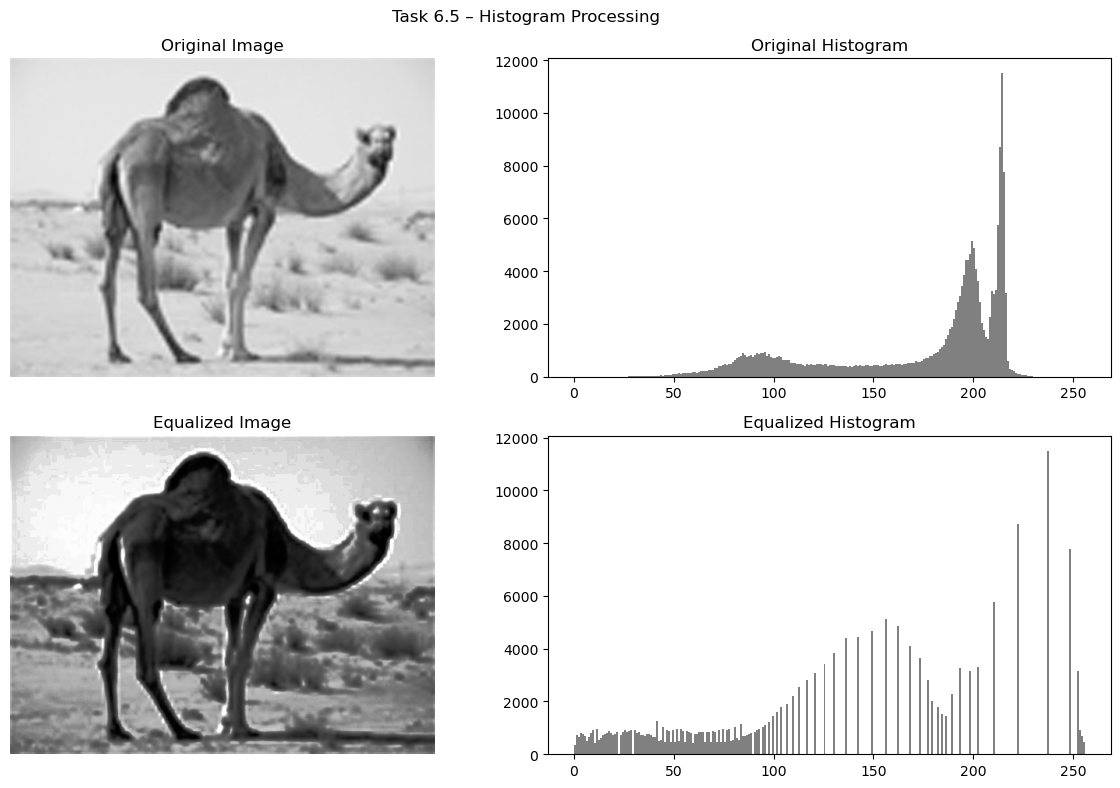

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_rgb  = cv2.imread('low.jpg')
img_rgb  = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

img_eq = cv2.equalizeHist(img_gray)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0,0].imshow(img_gray, cmap='gray'); axes[0,0].set_title('Original Image');      axes[0,0].axis('off')
axes[0,1].hist(img_gray.ravel(), 256, [0,256], color='gray'); axes[0,1].set_title('Original Histogram')
axes[1,0].imshow(img_eq,   cmap='gray'); axes[1,0].set_title('Equalized Image');     axes[1,0].axis('off')
axes[1,1].hist(img_eq.ravel(),   256, [0,256], color='gray'); axes[1,1].set_title('Equalized Histogram')
plt.suptitle('Task 6.5 – Histogram Processing')
plt.tight_layout()
plt.show()

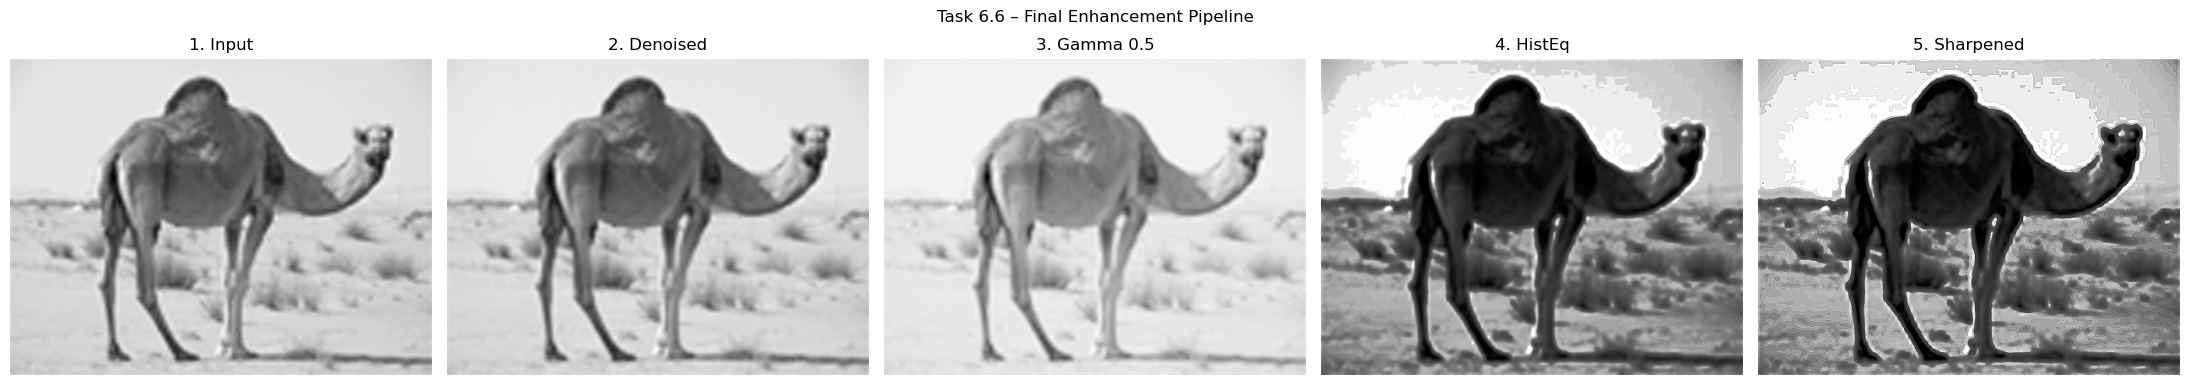

Saved as enhanced_output.jpg


In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_rgb  = cv2.imread('low.jpg')
img_rgb  = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

# Step 1: Denoise
step1 = cv2.GaussianBlur(img_gray, (5,5), 1)

# Step 2: Brighten with Gamma 0.5
step2 = (255 * (step1.astype(np.float64) / 255) ** 0.5).astype(np.uint8)

# Step 3: Histogram Equalization
step3 = cv2.equalizeHist(step2)

# Step 4: Sharpen
kernel  = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
enhanced = cv2.filter2D(step3, -1, kernel)

# Show pipeline
titles = ['1. Input', '2. Denoised', '3. Gamma 0.5', '4. HistEq', '5. Sharpened']
images = [img_gray,   step1,         step2,           step3,        enhanced]

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, img, title in zip(axes, images, titles):
    ax.imshow(img, cmap='gray')
    ax.set_title(title)
    ax.axis('off')
plt.suptitle('Task 6.6 – Final Enhancement Pipeline')
plt.tight_layout()
plt.show()

# Save
cv2.imwrite('enhanced_output.jpg', enhanced)
print("Saved as enhanced_output.jpg")